In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import CountVectorizer

In [2]:
movies = pd.read_csv("tmdb_5000_movies.csv")
credit = pd.read_csv("tmdb_5000_credit.csv")

In [3]:
print(movies.shape)
print(credit.shape)

(4803, 20)
(4803, 4)


In [4]:
movies.head(2)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500


In [5]:
credit.head(2)

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."


In [6]:
movies.columns

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count'],
      dtype='str')

In [7]:
credit.columns

Index(['movie_id', 'title', 'cast', 'crew'], dtype='str')

In [8]:
df=movies.merge(credit,on ="title")

In [9]:
df.head(2)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,movie_id,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,285,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."


In [10]:
df.shape

(4809, 23)

In [11]:
df.columns

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count', 'movie_id', 'cast', 'crew'],
      dtype='str')

In [12]:
df.columns =df.columns.str.strip()

In [13]:
df = df[['movie_id','title','overview','genres','keywords','cast','crew']]

In [14]:
df.isnull().sum()

movie_id    0
title       0
overview    3
genres      0
keywords    0
cast        0
crew        0
dtype: int64

In [15]:
df.dropna(inplace=True)

In [16]:
df.isnull().sum()

movie_id    0
title       0
overview    0
genres      0
keywords    0
cast        0
crew        0
dtype: int64

In [17]:
import ast

In [18]:
def convert(obj):
    L=[]
    for i in ast.literal_eval(obj):
        L.append(i["name"])
    return L

In [19]:
df['genres'] = df['genres'].apply(convert)

In [20]:
df['keywords'] = df['keywords'].apply(convert)

In [21]:
def convert3(obj):
    L=[]
    counter = 0
    for i in ast.literal_eval(obj):
        if counter!=3:
            L.append(i["name"])
            counter+=1
        else:
            break
    return L

df["cast"]=df["cast"].apply(convert3)
        

In [22]:
df.columns

Index(['movie_id', 'title', 'overview', 'genres', 'keywords', 'cast', 'crew'], dtype='str')

In [23]:
def fetch_director(obj):
    L=[]
    for i in ast.literal_eval(obj):
        if i["job"] == "Director":
            L.append(i["name"])
            break
    return L            

In [24]:
df["crew"] = df["crew"].apply(fetch_director)

In [25]:
df["cast"] =df["cast"].apply(lambda x: [i.replace(" ","") for i in x])
df["crew"] = df["crew"].apply(lambda x:[i.replace(" ","") for i in x])
df["keywords"] = df["keywords"].apply(lambda x:[i.replace(" ","") for i in x])
df["genres"] = df["genres"].apply(lambda x:[i.replace(" ","") for i in x])

In [26]:
df["overview"] = df["overview"].apply(lambda x:x.split())

In [27]:
df.columns

Index(['movie_id', 'title', 'overview', 'genres', 'keywords', 'cast', 'crew'], dtype='str')

In [28]:
df["tags"]= df["overview"]+df["genres"]+df["keywords"]+df["cast"]+df["crew"]

In [29]:
new_df = df[["movie_id","title","tags"]]

In [30]:
new_df["tags"] = new_df["tags"].apply(lambda x:" ".join(x))

In [31]:
new_df["tags"] = new_df["tags"].apply(lambda x:x.lower())

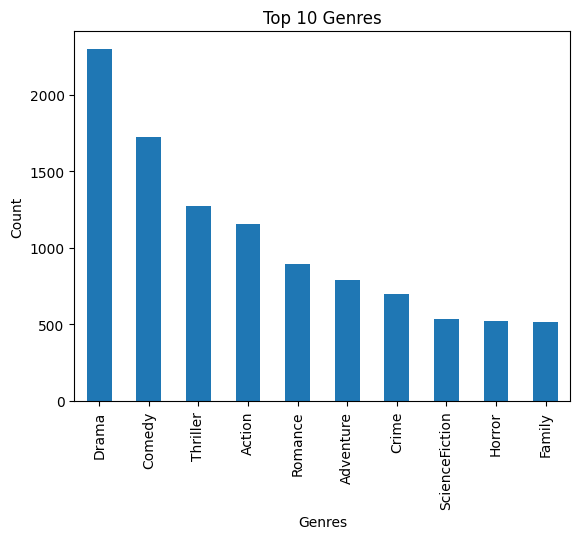

In [32]:
# explode genres
genre_df = df.explode('genres')

# count
genre_counts = genre_df['genres'].value_counts().head(10)

# plot
plt.figure()
genre_counts.plot(kind='bar')
plt.title("Top 10 Genres")
plt.xlabel("Genres")
plt.ylabel("Count")
plt.show()

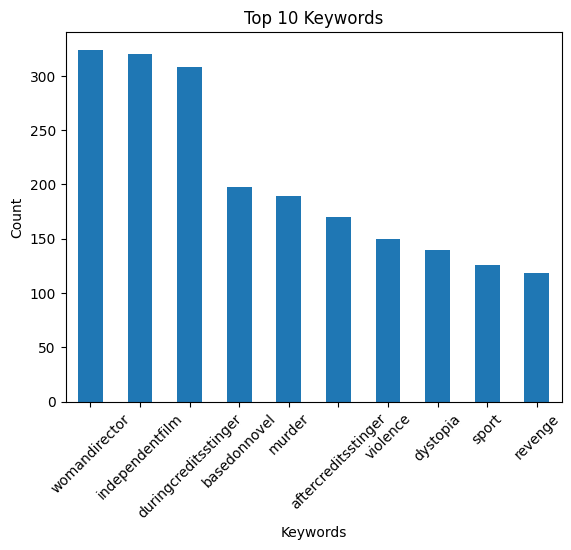

In [33]:
keyword_df = df.explode('keywords')

top_keywords = keyword_df['keywords'].value_counts().head(10)

plt.figure()
top_keywords.plot(kind='bar')
plt.title("Top 10 Keywords")
plt.xlabel("Keywords")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

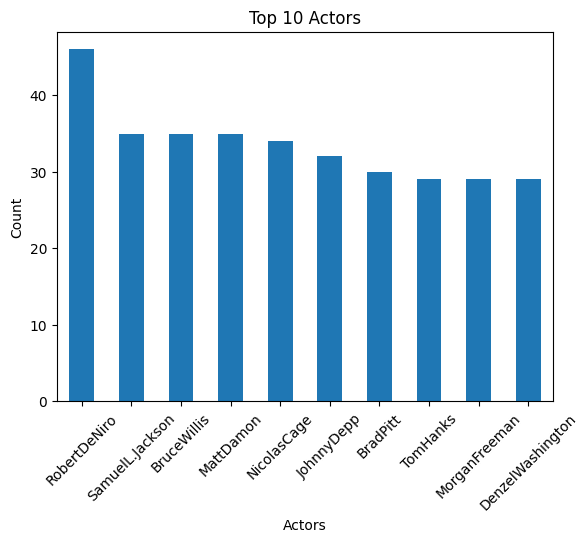

In [34]:
cast_df = df.explode('cast')

top_cast = cast_df['cast'].value_counts().head(10)

plt.figure()
top_cast.plot(kind='bar')
plt.title("Top 10 Actors")
plt.xlabel("Actors")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

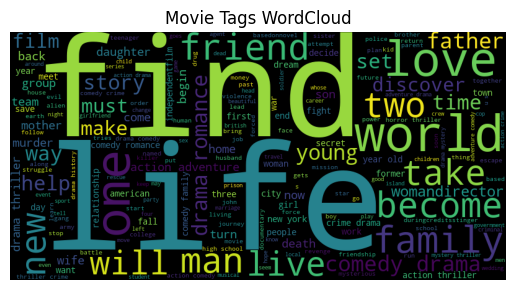

In [49]:
from wordcloud import WordCloud
text = " ".join(new_df['tags'])
wc = WordCloud(width=800, height=400).generate(text)
plt.figure()
plt.imshow(wc)
plt.axis('off')
plt.title("Movie Tags WordCloud")
plt.show()

In [39]:
cv = CountVectorizer()

In [40]:
vectors = cv.fit_transform(new_df['tags']).toarray()

In [41]:
similarity = cosine_similarity(vectors)

In [44]:
def recommend(movie):
    if movie not in new_df['title'].values:
        print("Movie not found ❌")
        return

    index = new_df[new_df['title'] == movie].index[0]
    distances = similarity[index]
    
    movies_list = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])
    
    print("\nRecommended Movies:\n")
    for i in movies_list[1:6]:
        print(new_df.iloc[i[0]].title)


Recommended Movies:

Aliens vs Predator: Requiem
Independence Day
Apollo 18
Battle: Los Angeles
Starship Troopers
